## Environment Setup and Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit, KFold

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

DATA_PATH = '/content/drive/MyDrive/Supply_Chain_Demand_Forecasting/data/processed/cleaned_sales_data.csv'

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print("Loaded:", df.shape)
df.head()

Mounted at /content/drive
Loaded: (9586222, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,units_sold,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,sell_price,snap,is_zero_sale,day_name
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,Saturday,1,1,2011,none,none,none,none,2.0,0,0,Saturday
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,Sunday,2,1,2011,none,none,none,none,2.0,0,1,Sunday
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,Monday,3,1,2011,none,none,none,none,2.0,0,1,Monday
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,Tuesday,4,2,2011,none,none,none,none,2.0,1,0,Tuesday
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,Wednesday,5,2,2011,none,none,none,none,2.0,1,0,Wednesday


## Building a Clean Series to Study

In [2]:
daily = df.groupby('date')['units_sold'].sum().reset_index()
daily = daily.set_index('date').asfreq('D')  # asfreq enforces one row per calendar day, no gaps

print("Any missing dates after asfreq?", daily['units_sold'].isnull().sum())
daily.head()

Any missing dates after asfreq? 0


,units_sold
date,
2011-01-29,6893
2011-01-30,6842
2011-01-31,4638
2011-02-01,5309
2011-02-02,4324


## Trend and Seasonality

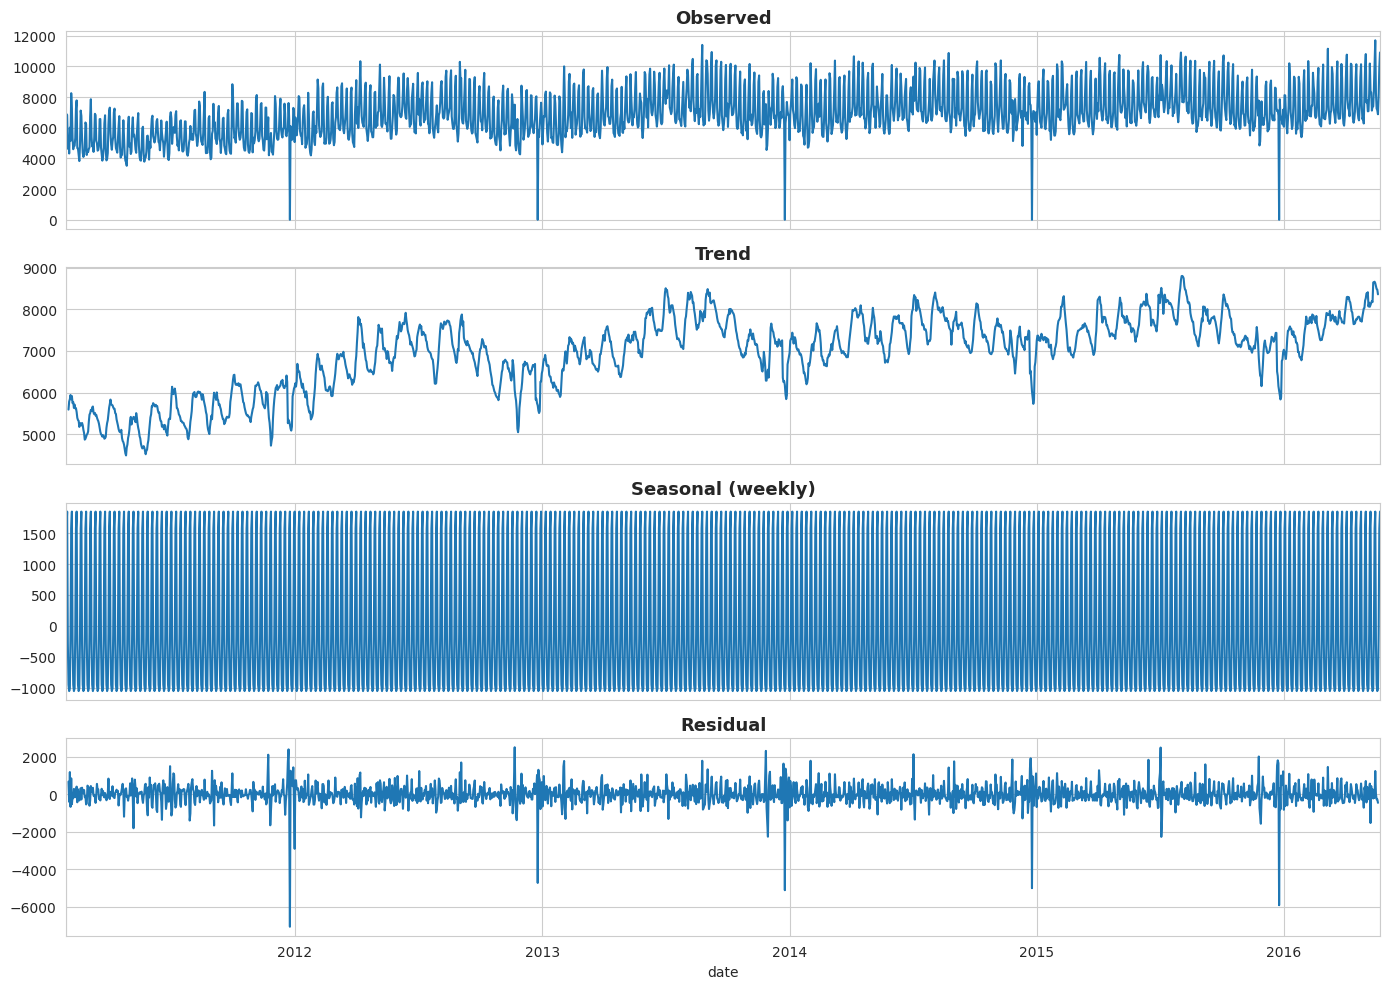

In [3]:
decomposition = seasonal_decompose(daily['units_sold'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (weekly)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

## Stationarity and the ADF Test

In [4]:
def run_adf_test(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical values: {result[4]}")
    if result[1] < 0.05:
        print("=> Reject H0: series IS stationary\n")
    else:
        print("=> Fail to reject H0: series is NOT stationary\n")
    return result[1]

adf_pvalue_raw = run_adf_test(daily['units_sold'], "Raw daily demand")

--- ADF Test: Raw daily demand ---
ADF Statistic: -1.9119
p-value: 0.3265
Critical values: {'1%': np.float64(-3.4337711555892523), '5%': np.float64(-2.8630512450631986), '10%': np.float64(-2.567574528530358)}
=> Fail to reject H0: series is NOT stationary



--- ADF Test: First-differenced daily demand ---
ADF Statistic: -21.8402
p-value: 0.0000
Critical values: {'1%': np.float64(-3.433772946369569), '5%': np.float64(-2.8630520356606137), '10%': np.float64(-2.567574949489954)}
=> Reject H0: series IS stationary



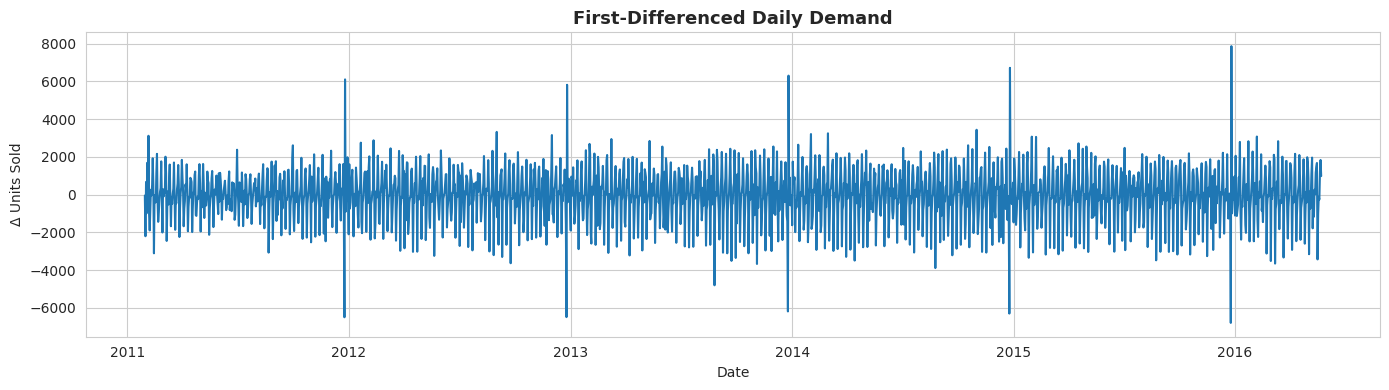

In [5]:
# Differencing: subtract each value from the one 1 day earlier.
# Intuition: differencing removes trend by looking at CHANGE rather than LEVEL.
daily['diff_1'] = daily['units_sold'].diff(1)

adf_pvalue_diff = run_adf_test(daily['diff_1'], "First-differenced daily demand")

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily['diff_1'])
plt.title('First-Differenced Daily Demand')
plt.xlabel('Date')
plt.ylabel('Δ Units Sold')
plt.tight_layout()
plt.show()

## Autocorrelation (ACF) and Partial Autocorrelation (PACF)

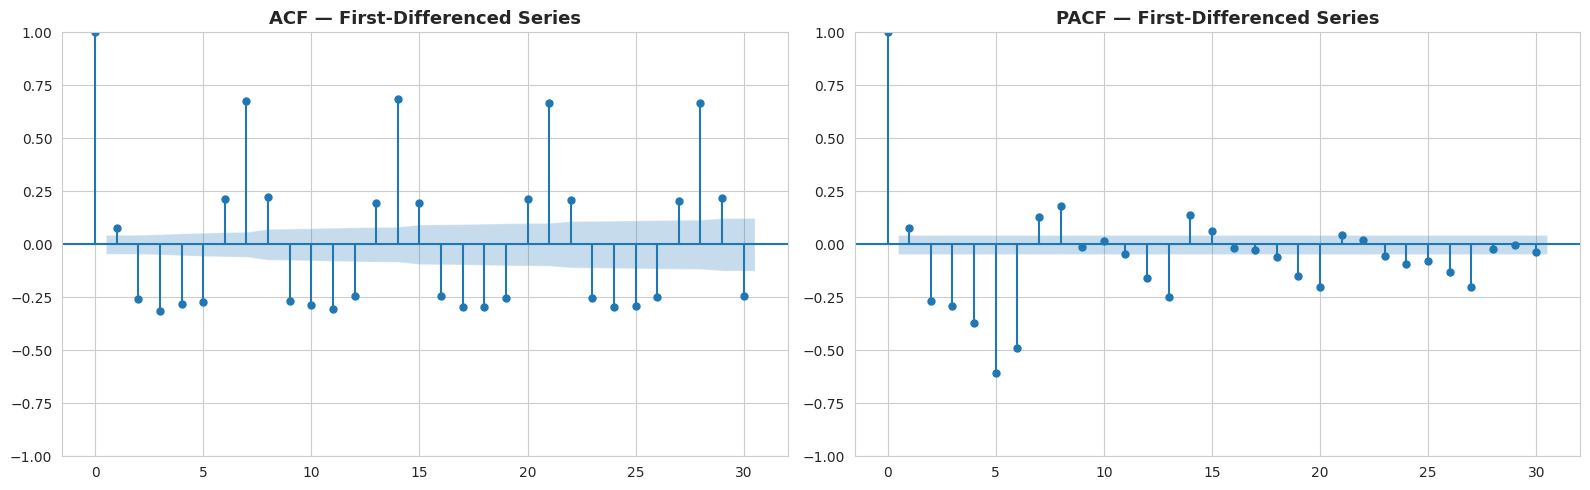

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(daily['diff_1'].dropna(), lags=30, ax=axes[0])
axes[0].set_title('ACF — First-Differenced Series')

plot_pacf(daily['diff_1'].dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF — First-Differenced Series')

plt.tight_layout()
plt.show()

## Why Random Train/Test Splits (and K-Fold) Are Wrong for Time Series

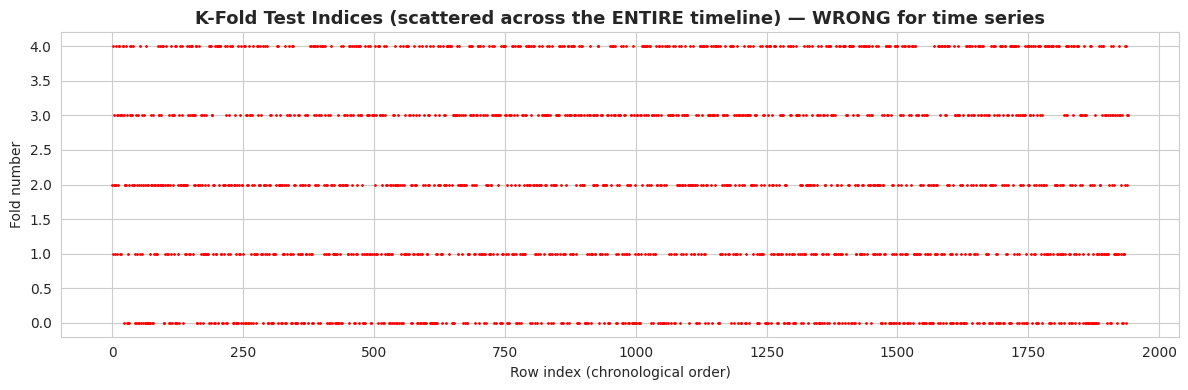

In [7]:
# Demonstration: what K-Fold does to a time-ordered index (do NOT use this for the real model)
n_samples = len(daily)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(12, 4))
for fold, (train_idx, test_idx) in enumerate(kfold.split(daily)):
    ax.scatter(test_idx, [fold] * len(test_idx), s=1, color='red')
ax.set_title('K-Fold Test Indices (scattered across the ENTIRE timeline) — WRONG for time series')
ax.set_xlabel('Row index (chronological order)')
ax.set_ylabel('Fold number')
plt.tight_layout()
plt.show()

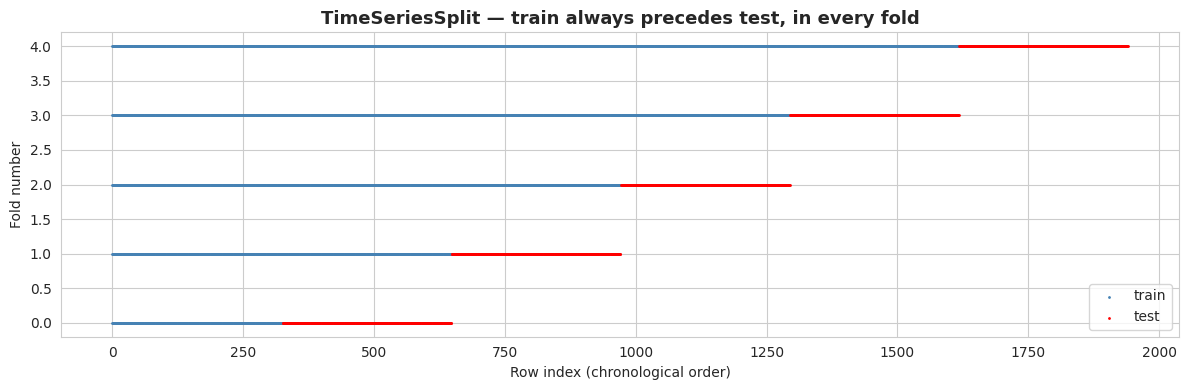

In [8]:
# TimeSeriesSplit: the correct approach -- each fold's test set comes strictly AFTER its train set
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(12, 4))
for fold, (train_idx, test_idx) in enumerate(tscv.split(daily)):
    ax.scatter(train_idx, [fold] * len(train_idx), s=1, color='steelblue', label='train' if fold == 0 else "")
    ax.scatter(test_idx, [fold] * len(test_idx), s=1, color='red', label='test' if fold == 0 else "")
ax.set_title('TimeSeriesSplit — train always precedes test, in every fold')
ax.set_xlabel('Row index (chronological order)')
ax.set_ylabel('Fold number')
ax.legend()
plt.tight_layout()
plt.show()

## Forecast Horizon and Walk-Forward Validation in Practice

In [9]:
FORECAST_HORIZON = 28  # days -- matches M5's official evaluation horizon

tscv = TimeSeriesSplit(n_splits=5, test_size=FORECAST_HORIZON)

for fold, (train_idx, test_idx) in enumerate(tscv.split(daily)):
    train_dates = daily.index[train_idx]
    test_dates = daily.index[test_idx]
    print(f"Fold {fold}: train {train_dates.min().date()} -> {train_dates.max().date()} "
          f"({len(train_idx)} days) | test {test_dates.min().date()} -> {test_dates.max().date()} "
          f"({len(test_idx)} days)")

Fold 0: train 2011-01-29 -> 2016-01-03 (1801 days) | test 2016-01-04 -> 2016-01-31 (28 days)
Fold 1: train 2011-01-29 -> 2016-01-31 (1829 days) | test 2016-02-01 -> 2016-02-28 (28 days)
Fold 2: train 2011-01-29 -> 2016-02-28 (1857 days) | test 2016-02-29 -> 2016-03-27 (28 days)
Fold 3: train 2011-01-29 -> 2016-03-27 (1885 days) | test 2016-03-28 -> 2016-04-24 (28 days)
Fold 4: train 2011-01-29 -> 2016-04-24 (1913 days) | test 2016-04-25 -> 2016-05-22 (28 days)


## Data Leakage: The Complete Checklist

In [10]:
# Demonstration: a rolling feature computed the WRONG way (leaky) vs the RIGHT way (safe)
demo = daily[['units_sold']].copy()

# LEAKY: uses centered window, which includes future values relative to each row
demo['rolling_mean_leaky'] = demo['units_sold'].rolling(window=7, center=True).mean()

# SAFE: uses only past values, shifted by 1 so today's row never sees today's own value
demo['rolling_mean_safe'] = demo['units_sold'].shift(1).rolling(window=7).mean()

demo.head(10)

,units_sold,rolling_mean_leaky,rolling_mean_safe
date,,,
2011-01-29,6893,NaN,NaN
2011-01-30,6842,NaN,NaN
2011-01-31,4638,NaN,NaN
2011-02-01,5309,5593.857143,NaN
2011-02-02,4324,5788.714286,NaN
2011-02-03,6010,5843.714286,NaN
2011-02-04,5141,5942.714286,NaN
2011-02-05,8257,5841.714286,5593.857143
2011-02-06,7227,5918.142857,5788.714286


## Key Takeaways

### Daily sales are non-stationary before differencing.
### First-order differencing improves stationarity.
### Random train/test splits leak future information.
### Walk-forward validation will be used in all subsequent modeling.